mkdir -p failed for path /home/bz/.config/matplotlib: [Errno 13] Permission denied: '/home/bz/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-5jn27rdt because there was an issue with the default path (/home/bz/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


   cycle     branch        type                        matchup forecastdate  \
0   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
1   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
2   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
3   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   
4   2016  President  polls-plus  Clinton vs. Trump vs. Johnson    2011/1/16   

      state   startdate     enddate                  pollster grade  ...  \
0      U.S.  10/25/2016  10/31/2016   Google Consumer Surveys     B  ...   
1      U.S.  10/27/2016  10/30/2016  ABC News/Washington Post    A+  ...   
2  Virginia  10/27/2016  10/30/2016  ABC News/Washington Post    A+  ...   
3   Florida  10/20/2016  10/24/2016                 SurveyUSA     A  ...   
4      U.S.  10/20/2016  10/25/2016       Pew Research Center    B+  ...   

   rawpoll_johnson rawpoll_mcmullin  adjpoll_clinton  adjpoll_trump 

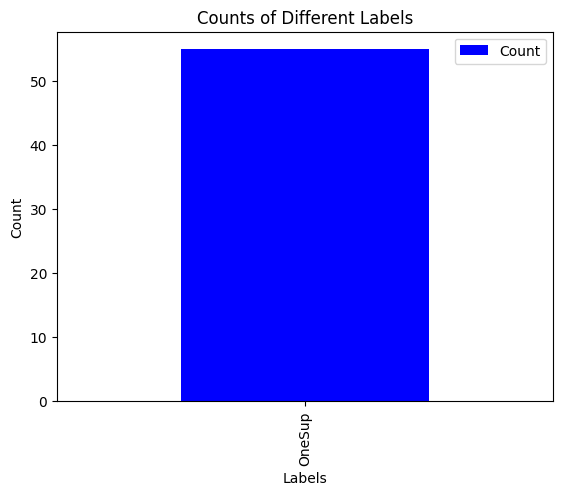

In [5]:
import pandas as pd

# 读取文件
df = pd.read_csv('25.presidential_polls.csv')

# 查看前5行
print(df.head(5))

# 查看后2行
print(df.tail(2))

# 选择指定列并丢弃缺失值
selected_df = df[['state', 'rawpoll_johnson', 'adjpoll_johnson']].dropna()

# 导出为文本文件，用空格分隔，每行末尾换行
selected_df.to_csv('presidential_polls_johnson.txt', sep=' ', index=False, header=True)

# 导出到文本文件
selected_df.to_csv('presidential_polls_johnson.txt', sep=' ', index=False, header=True)

# 读取文本文件
new_df = pd.read_csv('presidential_polls_johnson.txt', sep=' ')

# 按照state分组并计算均值
grouped_mean = new_df.groupby('state').mean()

# 导出到Excel文件
grouped_mean.to_excel('presidential_polls_johnson_state_mean.xlsx')

# 读取Excel文件
excel_df = pd.read_excel('presidential_polls_johnson_state_mean.xlsx')

# 进行离散化
excel_df['Label'] = pd.cut(excel_df['adjpoll_johnson'], bins=[0, 25, 50, 75, 100], labels=['OneSup', 'TwoSup', 'ThreeSup', 'FourSup'])

# 保存为CSV文件
excel_df.to_csv('presidential_polls_johnson_state_mean_lable.csv', index=False)

import matplotlib.pyplot as plt

# 读取CSV文件
final_df = pd.read_csv('presidential_polls_johnson_state_mean_lable.csv')

# 统计个数
counts = final_df['Label'].value_counts()

# 绘制柱状图
counts.plot(kind='bar', color='blue')
plt.title('Counts of Different Labels')
plt.xlabel('Labels')
plt.ylabel('Count')
plt.legend(['Count'])
plt.savefig('presidential_polls_johnson_state_support.png', dpi=300)